In [92]:
import pandas as pd 
import sklearn as sk
import os
import pandas as pd
import numpy as np 
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import scanpy as sc
import anndata as ad
import bbknn
from sklearn.decomposition import PCA
import numpy as np
import harmonypy as hm
GENE_PANEL = ["ATOH1","DLL1","DLL4","GFI1","AREG","HES1","HES5","JAG2","NOTCH1","NOTCH2","NOTCH3",
              "OLFM4","LEF1","APCDD1","WNT6","NEUROG3","NEUROD1","KRT20","NEURL1","LGR5"]

In [48]:
data_path='/mnt/cold2/snaketree/prj/PPH/local/share/data/saver_mat'
train_id=['CRC1502','CRC1620','CRC1139']
tratt_cercato=['cetux','CTX72h','NT','NT72H']
train=pd.DataFrame()
for file in os.listdir(data_path):
    sample_name=str.split(file,sep='_')[4]
    trattamento=str.split(file,sep='_')[5]
    if sample_name in train_id and trattamento in tratt_cercato:
        data=pd.read_csv(os.path.join(data_path,file),header=0,index_col=0)
        data=data.T
        data['sample']=sample_name
        data['cell_id']=data.index
        data['trattamento']=trattamento
        data.reset_index(drop=True,inplace=True)
        train=pd.concat([train,data])

In [49]:
from func_NT_cetux import *
n_hvg=1500
df=train
df_clean, dup = strip_prefix_from_genes(df, meta_cols=("cell_id","sample","trattamento"), sep=":", on_duplicate="first")

# 2) AnnData + raw
adata_full = make_anndata_from_df(
    df_clean,
    cell_col="cell_id",
    sample_col="sample",
    trattamento_col="trattamento",
    set_raw=True
)

In [50]:
from func_NT_cetux import *
n_hvg=1500


# 2) AnnData + raw
#adata_full = make_anndata_from_df(df_clean, set_raw=True)

# 3) cell cycle
score_cell_cycle(adata_full)

# 4) HVG + PCA
select_hvg_cell_ranger(adata_full, n_top_genes=n_hvg, batch_key="sample", subset=True)
scale_and_pca(adata_full, n_comps=42, max_value=10, random_state=42)
adata_base = adata_full

BEST = dict(
    n_pcs=20,          
    nwb=3,             
    trim=None,         
    leiden_res=0.3,    
    out_root="./bbknn_NT_cetux_KRAS"
)


# cartella output
def safe(s): return re.sub(r"[^A-Za-z0-9_=.,+-]", "_", str(s))
outdir = os.path.join(
    BEST["out_root"],
    f"npcs={BEST['n_pcs']}__nwb={BEST['nwb']}__trim={BEST['trim']}__res={BEST['leiden_res']}"
)
os.makedirs(outdir, exist_ok=True)
sc.settings.figdir = outdir

# 5)integrazione
adx = adata_base.copy()
bbknn.bbknn(
    adx,
    batch_key="sample",
    neighbors_within_batch=BEST['nwb'],
    trim=BEST["trim"],
    n_pcs=BEST["n_pcs"]
)
sc.tl.umap(adx, min_dist=0.3, random_state=42)  # UMAP usa il grafo BBKNN
save_umap_gene_panel(adx, outdir, GENE_PANEL)
# 6)clustering (Leiden)
clu_key = f"leiden_r{BEST['leiden_res']}"
sc.tl.leiden(adx, resolution=BEST["leiden_res"], key_added=clu_key, random_state=42)

# plot rapidi &
sc.pl.umap(adx, color=["sample", clu_key], ncols=2, wspace=0.3, frameon=False,
           show=False, save="_sample+cluster.png")
if "phase" in adx.obs:
    sc.pl.umap(adx, color=["phase"], frameon=False, show=False, save="_phase.png")

saving figure to file bbknn_NT_cetux_KRAS/npcs=20__nwb=3__trim=None__res=0.3/umap_genes_panel.png
saving figure to file bbknn_NT_cetux_KRAS/npcs=20__nwb=3__trim=None__res=0.3/umap_sample+cluster.png
saving figure to file bbknn_NT_cetux_KRAS/npcs=20__nwb=3__trim=None__res=0.3/umap_phase.png


In [53]:
data_obs=pd.DataFrame(adx.obs)
data_obs.to_csv(path_or_buf='bbknn_NT_cetux_KRAS/npcs=20__nwb=3__trim=None__res=0.3/obs_data.csv',index=False)

## Confronto


In [110]:
data_cetux_path='bbknn_NT_KRAS/npcs=20__nwb=3__trim=None__res=0.3/obs_data.csv'
data_cetux=pd.read_csv(data_cetux_path)
data_mixed_path='bbknn_NT_cetux_KRAS/npcs=20__nwb=3__trim=None__res=0.3/obs_data.csv'
data_mixed=pd.read_csv(data_mixed_path)

In [104]:
data_mixed=data_mixed[data_mixed['trattamento']=='cetux']

In [105]:
out_mixed = (
    data_mixed
      .assign(uid = data_mixed["sample"].astype(str) + "|" + data_mixed["cell_id"].astype(str))
      .rename(columns={"leiden_r0.3": "cluster"})
      [["uid", "cluster"]]
)
out=(data_cetux.rename(columns={"leiden_r0.3": "cluster_or"})
      [["uid", "cluster_or"]])


In [114]:
data_mixed[data_mixed['leiden_r0.3']==7]

,cell_id,sample,trattamento,uid,S_score,G2M_score,phase,leiden_r0.3
323,ACAGCCGAGTCCTGTA.1,CRC1502,cetux,CRC1502cetux|ACAGCCGAGTCCTGTA.1|cetux,1.813372,1.136450,S,7
1547,CAGTTCCAGATGAATC.1,CRC1502,cetux,CRC1502cetux|CAGTTCCAGATGAATC.1|cetux,1.628777,1.172495,S,7
2883,GATTCTTAGCTGAAAT.1,CRC1502,cetux,CRC1502cetux|GATTCTTAGCTGAAAT.1|cetux,1.718527,1.201736,S,7
5606,ACAGCCGAGTCCTGTA.1,CRC1502,NT,CRC1502NT|ACAGCCGAGTCCTGTA.1|NT,1.813372,1.136450,S,7
6830,CAGTTCCAGATGAATC.1,CRC1502,NT,CRC1502NT|CAGTTCCAGATGAATC.1|NT,1.628777,1.172495,S,7
8166,GATTCTTAGCTGAAAT.1,CRC1502,NT,CRC1502NT|GATTCTTAGCTGAAAT.1|NT,1.718527,1.201736,S,7


UID in comune: 12947  |  out: 12947  |  out_mixed: 12947
cluster_mixed     0     1     2     3     4    5  6  7
cluster_orig                                          
0              2795     0    97     2    90    4  0  0
1               806    22    22  1570    19   11  0  0
2                 0  1516   468     0     0    5  3  3
3               116   104  1612     0    43   11  0  0
4                 8     1     1     6  1682    3  0  0
5                13  1066   321     0     0    6  0  0
6                12    15     0    19     1  474  0  0


<Axes: xlabel='cluster_mixed', ylabel='cluster_orig'>

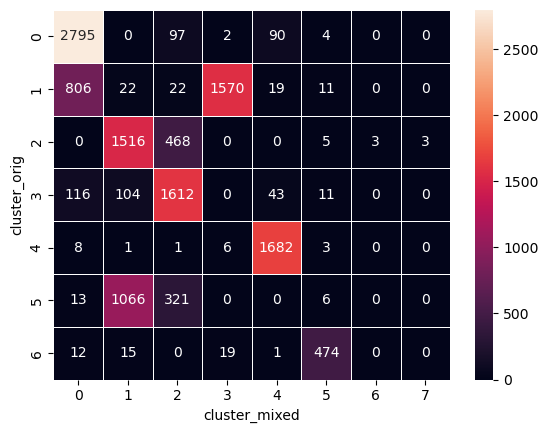

In [106]:
import pandas as pd
import seaborn as sns

m = out.merge(out_mixed, on="uid", how="inner", suffixes=("_or", "_mix"))

print(f"UID in comune: {len(m)}  |  out: {len(out)}  |  out_mixed: {len(out_mixed)}")


cm = pd.crosstab(m["cluster_or"], m["cluster"],
                 rownames=["cluster_orig"], colnames=["cluster_mixed"])

print(cm)






sns.heatmap(cm,annot=True, fmt="d", linewidths=.5)
